Устройство: cpu
Датасет: EMNIST
Размер train: 90240
Размер val: 22560
Размер test: 18800
Форма x: torch.Size([128, 1, 28, 28])
Форма y: torch.Size([128])
Минимум x: 0.0 Максимум x: 1.0
E1 | эпоха 01/12 | train_loss=1.1628 | train_acc=0.6566 | val_loss=0.6969 | val_acc=0.7821
E1 | эпоха 02/12 | train_loss=0.6082 | train_acc=0.8004 | val_loss=0.5818 | val_acc=0.8078
E1 | эпоха 03/12 | train_loss=0.4982 | train_acc=0.8299 | val_loss=0.5515 | val_acc=0.8191
E1 | эпоха 04/12 | train_loss=0.4355 | train_acc=0.8470 | val_loss=0.4955 | val_acc=0.8351
E1 | эпоха 05/12 | train_loss=0.3920 | train_acc=0.8606 | val_loss=0.4796 | val_acc=0.8415
E1 | эпоха 06/12 | train_loss=0.3575 | train_acc=0.8694 | val_loss=0.4744 | val_acc=0.8436
E1 | эпоха 07/12 | train_loss=0.3267 | train_acc=0.8779 | val_loss=0.4852 | val_acc=0.8327
E1 | эпоха 08/12 | train_loss=0.3040 | train_acc=0.8856 | val_loss=0.4862 | val_acc=0.8433
E1 | эпоха 09/12 | train_loss=0.2813 | train_acc=0.8924 | val_loss=0.4792 | val_acc=0.8

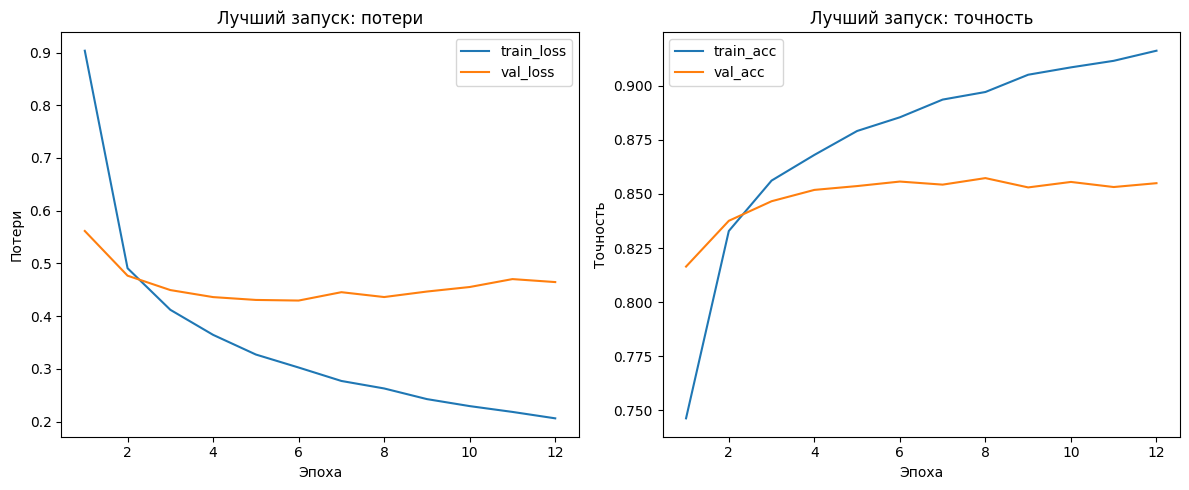

O1 | эпоха 01/6 | train_loss=1.6276 | train_acc=0.5332 | val_loss=1.0248 | val_acc=0.6882
O1 | эпоха 02/6 | train_loss=0.9958 | train_acc=0.6979 | val_loss=0.8418 | val_acc=0.7403
O1 | эпоха 03/6 | train_loss=0.8742 | train_acc=0.7341 | val_loss=0.8371 | val_acc=0.7429
O1 | эпоха 04/6 | train_loss=0.8051 | train_acc=0.7531 | val_loss=0.7326 | val_acc=0.7692
O1 | эпоха 05/6 | train_loss=0.7621 | train_acc=0.7653 | val_loss=0.7509 | val_acc=0.7765
O1 | эпоха 06/6 | train_loss=0.7330 | train_acc=0.7749 | val_loss=0.7111 | val_acc=0.7911
O2 | эпоха 01/6 | train_loss=3.3228 | train_acc=0.2340 | val_loss=2.9107 | val_acc=0.4125
O2 | эпоха 02/6 | train_loss=2.6896 | train_acc=0.4866 | val_loss=2.4796 | val_acc=0.5473
O2 | эпоха 03/6 | train_loss=2.3288 | train_acc=0.5813 | val_loss=2.1764 | val_acc=0.6132
O2 | эпоха 04/6 | train_loss=2.0533 | train_acc=0.6341 | val_loss=1.9287 | val_acc=0.6559
O2 | эпоха 05/6 | train_loss=1.8276 | train_acc=0.6700 | val_loss=1.7146 | val_acc=0.6848
O2 | эпоха

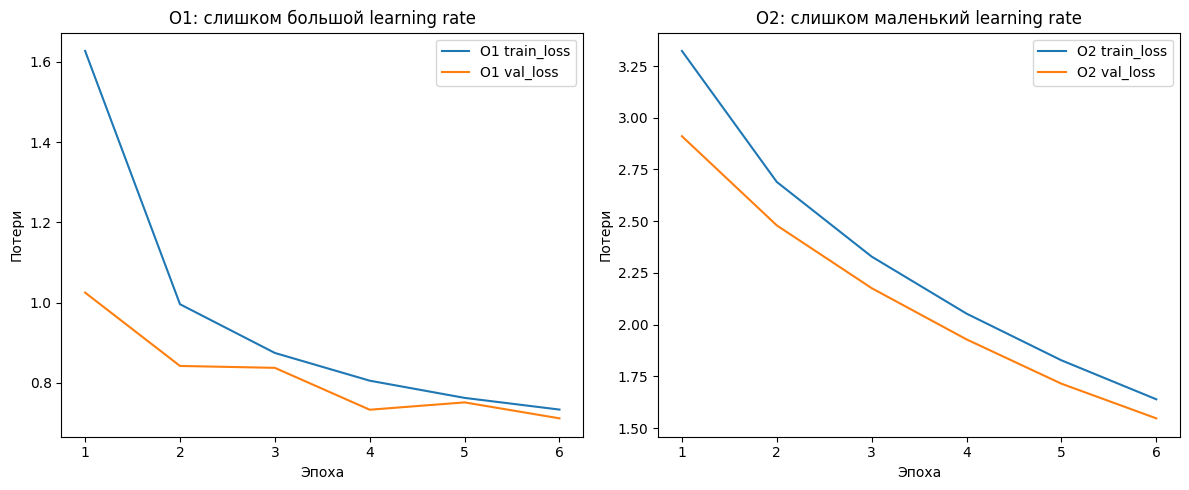

Сохранён файл: c:\Users\kiril\OneDrive\Desktop\ИИИ\REP\III_2025-26\homeworks\HW08-09\artifacts\runs.csv

Таблица результатов:
  experiment_id dataset  seed  \
0            E1  EMNIST    42   
1            E2  EMNIST    42   
2            E3  EMNIST    42   
3            E4  EMNIST    42   
4            O1  EMNIST    42   
5            O2  EMNIST    42   
6            O3  EMNIST    42   

                                       model_summary optimizer       lr  \
0  hidden=(512,256,128), ReLU, dropout=0.0, batch...      Adam  0.00100   
1  hidden=(512,256,128), ReLU, dropout=0.3, batch...      Adam  0.00100   
2  hidden=(512,256,128), ReLU, dropout=0.0, batch...      Adam  0.00100   
3  hidden=(512,256,128), ReLU, dropout=0.0, batch...      Adam  0.00100   
4  hidden=(512, 256, 128), ReLU, dropout=0.0, bat...      Adam  0.30000   
5  hidden=(512, 256, 128), ReLU, dropout=0.0, bat...      Adam  0.00001   
6  hidden=(512, 256, 128), ReLU, dropout=0.0, bat...       SGD  0.01000   

   momen

In [3]:
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


# 1. Фиксация seed, устройство и пути

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)


cwd = Path.cwd()

if (cwd / "artifacts").exists() and cwd.name == "HW08-09":
    BASE_DIR = cwd
elif (cwd / "homeworks" / "HW08-09").exists():
    BASE_DIR = cwd / "homeworks" / "HW08-09"
else:
    BASE_DIR = cwd

ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = BASE_DIR / "data"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)



# Загрузка датасета

DATASET_NAME = "EMNIST"
BATCH_SIZE = 128

def get_datasets(dataset_name):
    transform = transforms.ToTensor()

    if dataset_name == "KMNIST":
        train_dataset = datasets.KMNIST(root=str(DATA_DIR), train=True, download=True, transform=transform)
        test_dataset = datasets.KMNIST(root=str(DATA_DIR), train=False, download=True, transform=transform)
        input_dim = 28 * 28
        num_classes = 10

    elif dataset_name == "EMNIST":
        train_dataset = datasets.EMNIST(root=str(DATA_DIR), split="balanced", train=True, download=True, transform=transform)
        test_dataset = datasets.EMNIST(root=str(DATA_DIR), split="balanced", train=False, download=True, transform=transform)
        input_dim = 28 * 28
        num_classes = 47

    elif dataset_name == "CIFAR10":
        train_dataset = datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True, transform=transform)
        test_dataset = datasets.CIFAR10(root=str(DATA_DIR), train=False, download=True, transform=transform)
        input_dim = 32 * 32 * 3
        num_classes = 10

    else:
        raise ValueError("Неизвестный датасет")

    return train_dataset, test_dataset, input_dim, num_classes

train_full_dataset, test_dataset, input_dim, num_classes = get_datasets(DATASET_NAME)

train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(train_full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Датасет:", DATASET_NAME)
print("Размер train:", len(train_dataset))
print("Размер val:", len(val_dataset))
print("Размер test:", len(test_dataset))

# Проверка батча
x_batch, y_batch = next(iter(train_loader))
print("Форма x:", x_batch.shape)
print("Форма y:", y_batch.shape)
print("Минимум x:", x_batch.min().item(), "Максимум x:", x_batch.max().item())

# Модель MLP

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        in_features = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.net(x)

# Функции обучения и оценки

def accuracy_fn(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_acc += accuracy_fn(logits, y) * batch_size
        total_items += batch_size

    return total_loss / total_items, total_acc / total_items

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_acc += accuracy_fn(logits, y) * batch_size
            total_items += batch_size

    return total_loss / total_items, total_acc / total_items

def fit_model(
    experiment_id,
    model,
    train_loader,
    val_loader,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False,
    patience=4,
    dataset_name="EMNIST",
    seed=42,
    model_summary=""
):
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError("Неизвестное имя оптимизатора")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0

    stop_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"{experiment_id} | эпоха {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

        improved = False
        if val_acc > best_val_acc:
            improved = True
        elif val_acc == best_val_acc and val_loss < best_val_loss:
            improved = True

        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            stop_counter = 0
        else:
            stop_counter += 1

        if early_stopping and stop_counter >= patience:
            print(f"{experiment_id}: ранняя остановка на эпохе {epoch}")
            break

    model.load_state_dict(best_state)

    run_info = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch
    }

    return model, history, run_info


# Построение графиков

def plot_best_curves(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Потери")
    plt.title("Лучший запуск: потери")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Эпоха")
    plt.ylabel("Точность")
    plt.title("Лучший запуск: точность")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_lr_extremes(history_o1, history_o2, save_path):
    epochs1 = range(1, len(history_o1["train_loss"]) + 1)
    epochs2 = range(1, len(history_o2["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs1, history_o1["train_loss"], label="O1 train_loss")
    plt.plot(epochs1, history_o1["val_loss"], label="O1 val_loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Потери")
    plt.title("O1: слишком большой learning rate")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs2, history_o2["train_loss"], label="O2 train_loss")
    plt.plot(epochs2, history_o2["val_loss"], label="O2 val_loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Потери")
    plt.title("O2: слишком маленький learning rate")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# 6. Конфигурации 

base_hidden = (512, 256, 128)

all_runs = []
all_histories = {}

config_e1 = {
    "hidden_sizes": base_hidden,
    "dropout": 0.0,
    "use_batchnorm": False,
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs": 12,
    "early_stopping": False,
    "patience": 4,
    "model_summary": "hidden=(512,256,128), ReLU, dropout=0.0, batchnorm=False"
}

config_e2 = {
    "hidden_sizes": base_hidden,
    "dropout": 0.3,
    "use_batchnorm": False,
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs": 12,
    "early_stopping": False,
    "patience": 4,
    "model_summary": "hidden=(512,256,128), ReLU, dropout=0.3, batchnorm=False"
}

config_e3 = {
    "hidden_sizes": base_hidden,
    "dropout": 0.0,
    "use_batchnorm": True,
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs": 12,
    "early_stopping": False,
    "patience": 4,
    "model_summary": "hidden=(512,256,128), ReLU, dropout=0.0, batchnorm=True"
}

model_e1 = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_sizes=config_e1["hidden_sizes"],
    dropout=config_e1["dropout"],
    use_batchnorm=config_e1["use_batchnorm"]
).to(device)

model_e1, history_e1, run_e1 = fit_model(
    experiment_id="E1",
    model=model_e1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_name=config_e1["optimizer_name"],
    lr=config_e1["lr"],
    momentum=config_e1["momentum"],
    weight_decay=config_e1["weight_decay"],
    epochs=config_e1["epochs"],
    early_stopping=config_e1["early_stopping"],
    patience=config_e1["patience"],
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=config_e1["model_summary"]
)
all_runs.append(run_e1)
all_histories["E1"] = history_e1

model_e2 = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_sizes=config_e2["hidden_sizes"],
    dropout=config_e2["dropout"],
    use_batchnorm=config_e2["use_batchnorm"]
).to(device)

model_e2, history_e2, run_e2 = fit_model(
    experiment_id="E2",
    model=model_e2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_name=config_e2["optimizer_name"],
    lr=config_e2["lr"],
    momentum=config_e2["momentum"],
    weight_decay=config_e2["weight_decay"],
    epochs=config_e2["epochs"],
    early_stopping=config_e2["early_stopping"],
    patience=config_e2["patience"],
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=config_e2["model_summary"]
)
all_runs.append(run_e2)
all_histories["E2"] = history_e2

model_e3 = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_sizes=config_e3["hidden_sizes"],
    dropout=config_e3["dropout"],
    use_batchnorm=config_e3["use_batchnorm"]
).to(device)

model_e3, history_e3, run_e3 = fit_model(
    experiment_id="E3",
    model=model_e3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_name=config_e3["optimizer_name"],
    lr=config_e3["lr"],
    momentum=config_e3["momentum"],
    weight_decay=config_e3["weight_decay"],
    epochs=config_e3["epochs"],
    early_stopping=config_e3["early_stopping"],
    patience=config_e3["patience"],
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=config_e3["model_summary"]
)
all_runs.append(run_e3)
all_histories["E3"] = history_e3

# Выбор лучшего между E2 и E3 для E4

candidate_runs = [run_e2, run_e3]
candidate_runs_sorted = sorted(candidate_runs, key=lambda x: (x["best_val_accuracy"], -x["best_val_loss"]), reverse=True)
best_candidate = candidate_runs_sorted[0]

print("\nЛучший кандидат для E4:", best_candidate["experiment_id"])

if best_candidate["experiment_id"] == "E2":
    best_regularized_config = copy.deepcopy(config_e2)
else:
    best_regularized_config = copy.deepcopy(config_e3)

config_e4 = copy.deepcopy(best_regularized_config)
config_e4["epochs"] = 20
config_e4["early_stopping"] = True
config_e4["patience"] = 4
config_e4["model_summary"] = config_e4["model_summary"] + ", EarlyStopping=True"

model_e4 = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_sizes=config_e4["hidden_sizes"],
    dropout=config_e4["dropout"],
    use_batchnorm=config_e4["use_batchnorm"]
).to(device)

model_e4, history_e4, run_e4 = fit_model(
    experiment_id="E4",
    model=model_e4,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_name=config_e4["optimizer_name"],
    lr=config_e4["lr"],
    momentum=config_e4["momentum"],
    weight_decay=config_e4["weight_decay"],
    epochs=config_e4["epochs"],
    early_stopping=config_e4["early_stopping"],
    patience=config_e4["patience"],
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=config_e4["model_summary"]
)
all_runs.append(run_e4)
all_histories["E4"] = history_e4

# Сохранение лучшей модели E4

best_model_path = ARTIFACTS_DIR / "best_model.pt"
torch.save(model_e4.state_dict(), best_model_path)

best_config = {
    "dataset": DATASET_NAME,
    "seed": SEED,
    "input_dim": input_dim,
    "num_classes": num_classes,
    "hidden_sizes": list(config_e4["hidden_sizes"]),
    "dropout": config_e4["dropout"],
    "use_batchnorm": config_e4["use_batchnorm"],
    "optimizer": config_e4["optimizer_name"],
    "lr": config_e4["lr"],
    "momentum": config_e4["momentum"],
    "weight_decay": config_e4["weight_decay"],
    "epochs": config_e4["epochs"],
    "early_stopping": config_e4["early_stopping"],
    "patience": config_e4["patience"]
}

best_config_path = ARTIFACTS_DIR / "best_config.json"
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=4)

print("Сохранено:")
print(best_model_path)
print(best_config_path)


# График лучшего прогона

best_curve_path = FIGURES_DIR / "curves_best.png"
plot_best_curves(history_e4, best_curve_path)


fixed_hidden = config_e4["hidden_sizes"]
fixed_dropout = config_e4["dropout"]
fixed_bn = config_e4["use_batchnorm"]

config_o1 = {
    "hidden_sizes": fixed_hidden,
    "dropout": fixed_dropout,
    "use_batchnorm": fixed_bn,
    "optimizer_name": "Adam",
    "lr": 3e-1,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs": 6,
    "early_stopping": False,
    "patience": 4,
    "model_summary": f"hidden={fixed_hidden}, ReLU, dropout={fixed_dropout}, batchnorm={fixed_bn}"
}

model_o1 = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_sizes=config_o1["hidden_sizes"],
    dropout=config_o1["dropout"],
    use_batchnorm=config_o1["use_batchnorm"]
).to(device)

model_o1, history_o1, run_o1 = fit_model(
    experiment_id="O1",
    model=model_o1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_name=config_o1["optimizer_name"],
    lr=config_o1["lr"],
    momentum=config_o1["momentum"],
    weight_decay=config_o1["weight_decay"],
    epochs=config_o1["epochs"],
    early_stopping=config_o1["early_stopping"],
    patience=config_o1["patience"],
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=config_o1["model_summary"]
)
all_runs.append(run_o1)
all_histories["O1"] = history_o1

config_o2 = {
    "hidden_sizes": fixed_hidden,
    "dropout": fixed_dropout,
    "use_batchnorm": fixed_bn,
    "optimizer_name": "Adam",
    "lr": 1e-5,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs": 6,
    "early_stopping": False,
    "patience": 4,
    "model_summary": f"hidden={fixed_hidden}, ReLU, dropout={fixed_dropout}, batchnorm={fixed_bn}"
}

model_o2 = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_sizes=config_o2["hidden_sizes"],
    dropout=config_o2["dropout"],
    use_batchnorm=config_o2["use_batchnorm"]
).to(device)

model_o2, history_o2, run_o2 = fit_model(
    experiment_id="O2",
    model=model_o2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_name=config_o2["optimizer_name"],
    lr=config_o2["lr"],
    momentum=config_o2["momentum"],
    weight_decay=config_o2["weight_decay"],
    epochs=config_o2["epochs"],
    early_stopping=config_o2["early_stopping"],
    patience=config_o2["patience"],
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=config_o2["model_summary"]
)
all_runs.append(run_o2)
all_histories["O2"] = history_o2

config_o3 = {
    "hidden_sizes": fixed_hidden,
    "dropout": fixed_dropout,
    "use_batchnorm": fixed_bn,
    "optimizer_name": "SGD",
    "lr": 1e-2,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "epochs": 12,
    "early_stopping": False,
    "patience": 4,
    "model_summary": f"hidden={fixed_hidden}, ReLU, dropout={fixed_dropout}, batchnorm={fixed_bn}"
}

model_o3 = MLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_sizes=config_o3["hidden_sizes"],
    dropout=config_o3["dropout"],
    use_batchnorm=config_o3["use_batchnorm"]
).to(device)

model_o3, history_o3, run_o3 = fit_model(
    experiment_id="O3",
    model=model_o3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_name=config_o3["optimizer_name"],
    lr=config_o3["lr"],
    momentum=config_o3["momentum"],
    weight_decay=config_o3["weight_decay"],
    epochs=config_o3["epochs"],
    early_stopping=config_o3["early_stopping"],
    patience=config_o3["patience"],
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=config_o3["model_summary"]
)
all_runs.append(run_o3)
all_histories["O3"] = history_o3


#График экстремальных learning rate

lr_extremes_path = FIGURES_DIR / "curves_lr_extremes.png"
plot_lr_extremes(history_o1, history_o2, lr_extremes_path)


#Сохранение runs.csv

runs_df = pd.DataFrame(all_runs)

cols_order = [
    "experiment_id",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "momentum",
    "weight_decay",
    "epochs_trained",
    "best_val_accuracy",
    "best_val_loss",
    "best_epoch"
]
runs_df = runs_df[cols_order]

runs_csv_path = ARTIFACTS_DIR / "runs.csv"
runs_df.to_csv(runs_csv_path, index=False, encoding="utf-8")
print("Сохранён файл:", runs_csv_path)

print("\nТаблица результатов:")
print(runs_df)


# Проверка лучшей модели на test

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)

print("\nФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ E4 НА TEST")
print(f"test_loss = {test_loss:.4f}")
print(f"test_accuracy = {test_acc:.4f}")
